In [20]:
import os
import math
import json
import  cv2
import gc
import fiona
import rasterio
import nest_asyncio
from scipy import stats
import openpyxl
import numpy as np
import pandas as pd
import seaborn as sns
import geopandas as gpd
import dataframe_image as dfi
from rasterio.features import geometry_mask
from pathlib import Path
from rasterio import features
from itertools import combinations
import scipy.stats as stats
import xml.etree.ElementTree as ET
from rasterio.plot import show, reshape_as_image
from rasterio.mask import mask
from rasterio.windows import from_bounds
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.transforms import Affine2D
from matplotlib_scalebar.scalebar import ScaleBar
from scipy.spatial import distance
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from shapely.geometry import box
from rasterstats import zonal_stats
import statsmodels.api as sm
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, f1_score, balanced_accuracy_score, recall_score
from skimage.feature import graycomatrix, graycoprops
fiona.drvsupport.supported_drivers['KML'] = 'rw'
from rasterio.warp import calculate_default_transform, reproject, Resampling
from skimage.registration import phase_cross_correlation

In [18]:
#BASE
path_base = "C:/Users/48755625H/Nextcloud/PhD ICA-CSIC/ESA_PP0106977"
#SHAPEFILES
shp_pln = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Patches_PlnScope_EPSG32630.shp"
shp_wv2 = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024-05-23_LaPoveda_Maiz-Sorgo_Patches_wv-02_EsquinaII_EPSG32630.shp"
shp_bounds = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024_bounds_Maiz-Sorgo_plot.shp"
shp_bounds_wv2 = Path(path_base) / "06_QGIS/23-05-2024_QGis_MaízLaPoveda/2024_bounds_Maiz-Sorgo_plot_wv2.shp"
#RASTER-IMAGERY
ortho_path = Path(path_base) / "01_img_data/drone/DJI Matrice 300 RTK/2024-06-13_MaízPoveda_RGB_20m_Orthomosaic.tif"
out_pln = Path(path_base) / "01_img_data/satellite/PlanetScope/20240613_111156_44_24fc_3B_AnalyticMS_SR_8b_harmonized_BOA.tif"
out_pan_wv2 = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-P3DS-050518203010_01_P001_BOA.TIF"
out_ms_wv2 = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA.TIF"
#PANSHARPENING
pansharp_BROV = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_simple_brovey.TIF"
pansharp_MEAN = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_simple_mean.TIF"
pansharp_ESRI = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_esri.TIF"
pansharp_GS = Path(path_base) / "01_img_data/satellite/worldview-2/24JUN11104156-M3DS-050518203010_01_P001_BOA_PAN_gram_schmidt.TIF"
#DATASETS-RODALES
path_dfA = Path(path_base) / "07_datasets/Dataset_1_Planet_3m.xlsx"
path_dfB = Path(path_base) / "07_datasets/Dataset_2_WV2_MS_2m.xlsx"
path_dfC = Path(path_base) / "07_datasets/Dataset_3_WV2_Pansharp_GS_05m.xlsx"

**Comparativa pixeles de centroide y píxeles de borde incluidos en el cálculo espectral medio de cada rodal por tamaño**

- ANÁLISIS A (Pansharpening WV2) -> Rodales viables retenidos: 246 (Conserva clase 'Low')
- ANÁLISIS B (WV2 vs Planet) -> Rodales viables retenidos: 121 (Clase 'Low' descartada por resolución de 3m)

In [4]:
def contar_pixeles_rodal(geom, src):
    """
    Calcula cuántos píxeles contribuyen a la media (centroide dentro) 
    y cuántos son solo de borde (tocados pero centroide fuera).
    """
    # 1. Obtener la caja envolvente (bounding box) del polígono con un margen de 1 píxel
    res = src.res[0]
    minx, miny, maxx, maxy = geom.bounds
    ventana = from_bounds(minx - res, miny - res, maxx + res, maxy + res, src.transform)
    ventana = ventana.round_lengths().round_offsets()
    
    # Transformación espacial local para esa ventanita
    win_transform = src.window_transform(ventana)
    out_shape = (ventana.height, ventana.width)
    
    if out_shape[0] <= 0 or out_shape[1] <= 0:
        return 0, 0
        
    # 2. Máscara 1: Solo píxeles cuyo centro cae DENTRO del polígono (all_touched=False)
    mask_centros = features.geometry_mask(
        [geom], out_shape=out_shape, transform=win_transform, 
        all_touched=False, invert=True
    )
    
    # 3. Máscara 2: TODOS los píxeles que son tocados por el polígono (all_touched=True)
    mask_tocados = features.geometry_mask(
        [geom], out_shape=out_shape, transform=win_transform, 
        all_touched=True, invert=True
    )
    
    # 4. Cálculos
    pixeles_centro = mask_centros.sum()
    pixeles_totales = mask_tocados.sum()
    pixeles_borde = pixeles_totales - pixeles_centro
    
    return pixeles_centro, pixeles_borde

def analizar_cobertura_pixeles(dict_imagenes, col_clase='Patch_size'):
    """
    Itera sobre las imágenes y sus shapefiles correspondientes para calcular
    el área media y la distribución de píxeles por clase.
    """
    resultados_totales = []
    
    for nombre, config in dict_imagenes.items():
        print(f"Procesando: {nombre}...")
        ruta_raster = config['raster']
        ruta_shp = config['shp']
        
        # Cargar shapefile
        gdf = gpd.read_file(ruta_shp)
        # Calcular área geométrica real en m2
        gdf['Area_m2'] = gdf.geometry.area
        
        # Abrir imagen para leer su cuadrícula espacial
        with rasterio.open(ruta_raster) as src:
            # Aplicar la función a cada polígono
            conteos = gdf.geometry.apply(lambda g: contar_pixeles_rodal(g, src))
            
            # Separar los resultados en dos columnas
            gdf['Px_Centro (Útiles)'] = [c[0] for c in conteos]
            gdf['Px_Borde (Descarte)'] = [c[1] for c in conteos]
        
        # Agrupar por clase para sacar las medias
        resumen = gdf.groupby(col_clase).agg({
            'Area_m2': 'mean',
            'Px_Centro (Útiles)': 'mean',
            'Px_Borde (Descarte)': 'mean'
        }).reset_index()
        
        resumen['Imagen'] = nombre
        resultados_totales.append(resumen)
        
    # Unir todos los resultados en un solo DataFrame
    df_final = pd.concat(resultados_totales, ignore_index=True)
    
    # Reordenar columnas para una lectura más limpia
    df_final = df_final[['Imagen', col_clase, 'Area_m2', 'Px_Centro (Útiles)', 'Px_Borde (Descarte)']]
    
    # Redondear a 2 decimales para que sea legible
    return df_final.round(2)

# ==========================================
# EJECUCIÓN
# ==========================================
# Diccionario con tus 3 escenarios vinculando cada imagen a su shapefile correcto
configuracion = {
    'Planet MS (3m)': {
        'raster': out_pln, # Ruta a tu TIF de Planet
        'shp': shp_pln   # Ruta a tu SHP de Planet
    },
    'Wv-02 MS (2m)': {
        'raster': out_ms_wv2,     # Ruta a tu TIF original de WV2
        'shp': shp_wv2   # Ruta a tu SHP de WV2
    },
    'Wv-02 PS (0.5m)': {
        'raster': pansharp_GS, # Ruta a un TIF pansharpened (ej. Gram-Schmidt)
        'shp': shp_wv2         # WV2 comparte el mismo SHP
    }
}

df_cobertura = analizar_cobertura_pixeles(configuracion)
orden_logico = ['High', 'Medium', 'Low', 'no-sorgo']
df_cobertura['Patch_size'] = pd.Categorical(
    df_cobertura['Patch_size'], 
    categories=orden_logico, 
    ordered=True)
df_cobertura = df_cobertura.sort_values(by=['Imagen', 'Patch_size']).reset_index(drop=True)
print("\n📊 TABLA DE COBERTURA: Píxeles Centrales vs Borde por Clase")
print("-" * 80)
display(df_cobertura)

Procesando: Planet MS (3m)...
Procesando: Wv-02 MS (2m)...
Procesando: Wv-02 PS (0.5m)...

📊 TABLA DE COBERTURA: Píxeles Centrales vs Borde por Clase
--------------------------------------------------------------------------------


,Imagen,Patch_size,Area_m2,Px_Centro (Útiles),Px_Borde (Descarte)
0,Planet MS (3m),High,55.22,6.12,8.25
1,Planet MS (3m),Medium,2.12,0.22,2.28
2,Planet MS (3m),Low,0.20,0.02,1.18
3,Planet MS (3m),no-sorgo,119.85,13.22,10.40
4,Wv-02 MS (2m),High,55.22,13.91,12.19
5,Wv-02 MS (2m),Medium,2.12,0.48,3.24
6,Wv-02 MS (2m),Low,0.20,0.05,1.27
7,Wv-02 MS (2m),no-sorgo,119.85,29.91,15.76
8,Wv-02 PS (0.5m),High,55.22,220.62,64.14
9,Wv-02 PS (0.5m),Medium,2.12,8.55,10.66


🎨 Generando Gráfica de Porcentajes de Pureza...


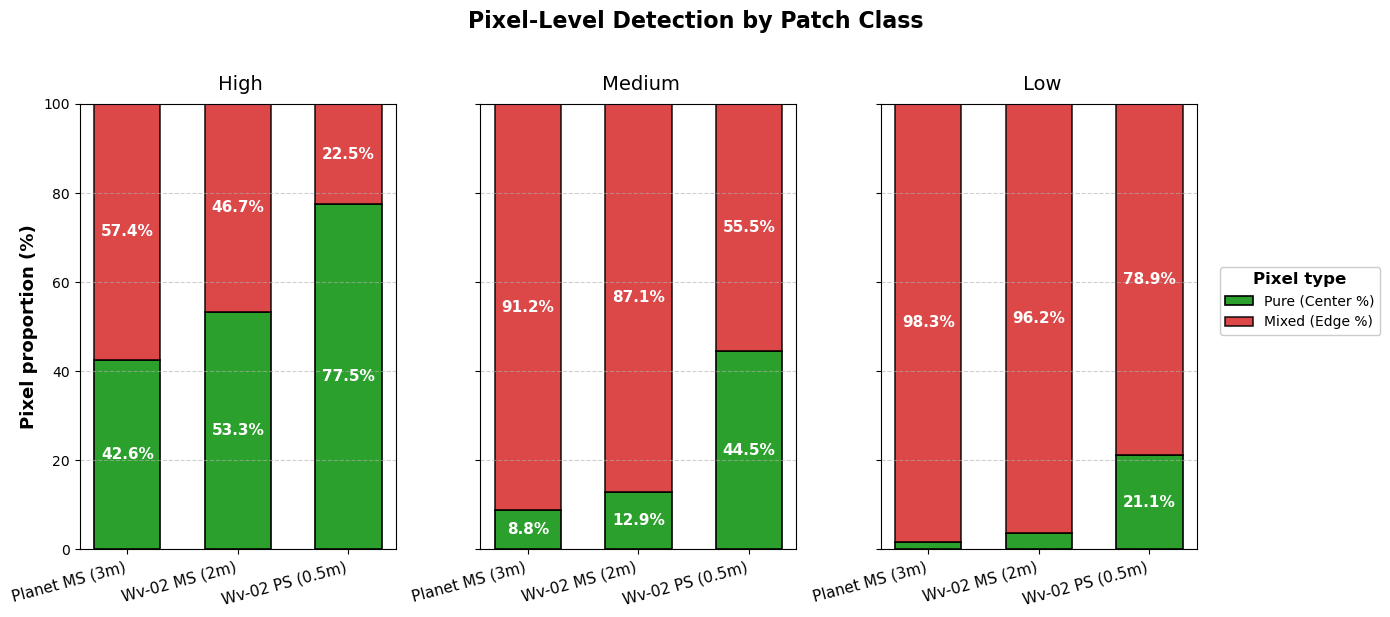

In [5]:
def graficar_porcentajes_cobertura(df_cobertura, col_clase='Patch_size'):
    print("🎨 Generando Gráfica de Porcentajes de Pureza...")
    
    # 1. Copiar y preparar porcentajes
    df = df_cobertura.copy()
    df['Total_Px'] = df['Px_Centro (Útiles)'] + df['Px_Borde (Descarte)']
    
    df['% Centro (Puro)'] = np.where(df['Total_Px'] > 0, 
                                     (df['Px_Centro (Útiles)'] / df['Total_Px']) * 100, 0)
    df['% Borde (Mixto)'] = np.where(df['Total_Px'] > 0, 
                                     (df['Px_Borde (Descarte)'] / df['Total_Px']) * 100, 100)
    
    clases = [c for c in df[col_clase].unique() if c != 'no-sorgo']
    imagenes = df['Imagen'].unique()
    
    # 2. Configurar figura
    fig, axes = plt.subplots(1, len(clases), figsize=(14, 6), sharey=True)
    fig.suptitle('Pixel-Level Detection by Patch Class', 
                 fontsize=16, fontweight='bold', y=1.02)
    
    color_puro = '#2ca02c'   
    color_mixto = '#d62728'  
    
    x_pos = np.arange(len(imagenes))
    width = 0.6
    
    for i, clase in enumerate(clases):
        ax = axes[i] if len(clases) > 1 else axes
        
        datos_clase = df[df[col_clase] == clase].set_index('Imagen').reindex(imagenes)
        pct_puro = datos_clase['% Centro (Puro)'].fillna(0).values
        pct_mixto = datos_clase['% Borde (Mixto)'].fillna(100).values
        
        barras_p = ax.bar(x_pos, pct_puro, width, label='Pure (Center %)', 
                          color=color_puro, edgecolor='black', linewidth=1.2)
        
        barras_m = ax.bar(x_pos, pct_mixto, width, bottom=pct_puro, label='Mixed (Edge %)', 
                          color=color_mixto, edgecolor='black', linewidth=1.2, alpha=0.85)
        
        # Textos interiores
        for j in range(len(x_pos)):
            if pct_puro[j] > 5:
                ax.text(x_pos[j], pct_puro[j]/2, f"{pct_puro[j]:.1f}%", 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)
            
            if pct_mixto[j] > 5:
                ax.text(x_pos[j], pct_puro[j] + (pct_mixto[j]/2), f"{pct_mixto[j]:.1f}%", 
                        ha='center', va='center', color='white', fontweight='bold', fontsize=11)
        
        # Estética
        ax.set_title(f" {clase}", fontsize=14, pad=10)
        ax.set_xticks(x_pos)
        ax.set_xticklabels(imagenes, rotation=15, ha='right', fontsize=11)
        ax.set_ylim(0, 100)
        ax.grid(axis='y', linestyle='--', alpha=0.6)
        
        if i == 0:
            ax.set_ylabel('Pixel proportion (%)', fontsize=13, fontweight='bold')
            
        if pct_puro[0] == 0:
            ax.text(x_pos[0], 105, "¡100% Ruido!", color='red', ha='center', fontsize=10, fontweight='bold')

    # =========================================================================
    # 🚨 LA MAGIA DE LA LEYENDA AQUÍ 🚨
    # Se ancla EXCLUSIVAMENTE al último gráfico (axes[-1]) y se escupe hacia la derecha
    # =========================================================================
    axes[-1].legend(title='Pixel type', 
                    title_fontproperties={'weight':'bold', 'size':12},
                    loc='upper left', 
                    bbox_to_anchor=(1.05, 0.65), 
                    framealpha=1)

    # El tight_layout reajusta los márgenes para que la leyenda quepa en la imagen exportada
    plt.tight_layout()
    plt.show()

# Ejecución
graficar_porcentajes_cobertura(df_cobertura)

**Analisis exploratorio de los datos (EDA)**
- **WorldView-2:** 1,Coastal Blue  2,Blue  3,Green   4,Yellow  5,Red  6,Red Edge  7,Near-Infrared 1  8,Near-Infrared 2
- ANOTA LAS LONGITUDES DE ONDA DE CADA BANDA
- **PlanetScope:** 1,Coastal Blue  2,Blue  3,Green I   4,Green II  5,Yellow  6,Red  7,Red Edge   8,Near-Infrared
- ANOTA LAS LONGITUDES DE ONDA DE CADA BANDA

In [6]:
dfA = pd.read_excel(path_dfA)
dfB = pd.read_excel(path_dfB)
dfC = pd.read_excel(path_dfC)

In [7]:
dfB

,ID_patch,Patch_size,Area_m2,WV2_2m_B1,WV2_2m_B2,WV2_2m_B3,WV2_2m_B4,WV2_2m_B5,WV2_2m_B6,WV2_2m_B7,WV2_2m_B8,WV2_2m_NDVI,WV2_2m_NDRE
0,p-0001,Low,0.111,0.024041,0.042715,0.073803,0.108181,0.160178,0.186850,0.303446,0.360760,0.309017,0.237806
1,p-0002,Low,0.040,0.024041,0.042715,0.073803,0.108181,0.160178,0.186850,0.303446,0.360760,0.309017,0.237806
2,p-0003,Low,0.793,0.024041,0.044254,0.074347,0.110847,0.164252,0.184866,0.292342,0.351780,0.280533,0.225219
3,p-0004,Low,0.064,0.020416,0.038674,0.067075,0.093869,0.137342,0.200131,0.354714,0.412344,0.441764,0.278605
4,p-0005,Low,0.688,0.019970,0.037712,0.066192,0.091624,0.133160,0.198605,0.358097,0.416178,0.457880,0.286495
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1876,p-1877,no-sorgo,489.383,0.019234,0.035725,0.064422,0.089415,0.129136,0.188480,0.327428,0.382597,0.434316,0.269329
1877,p-1878,no-sorgo,275.455,0.021255,0.039220,0.068467,0.099423,0.146960,0.184482,0.298157,0.351921,0.339680,0.235529
1878,p-1879,no-sorgo,182.938,0.021942,0.039837,0.069719,0.101479,0.151303,0.184410,0.292150,0.344692,0.317614,0.226077
1879,p-1880,no-sorgo,212.915,0.020545,0.037812,0.066654,0.094852,0.140622,0.180866,0.293876,0.345611,0.352714,0.238044


🚀 INICIANDO EDA DE ALTO IMPACTO...

📊 1. BALANCE DE CLASES (TARGET):
Patch_size
Low         84.6
Medium       9.6
High         3.4
no-sorgo     2.4
Name: proportion, dtype: float64 %
--------------------------------------------------
🔗 2. ALERTA DE MULTICOLINEALIDAD (> 0.90 Pearson):
⚠️ Hay 2 variables redundantes.
Ejemplos: ['PS_3m_NDVI', 'PS_3m_NDRE']...
--------------------------------------------------

🗺️ GENERANDO MAPA DE CALOR DE CORRELACIÓN...


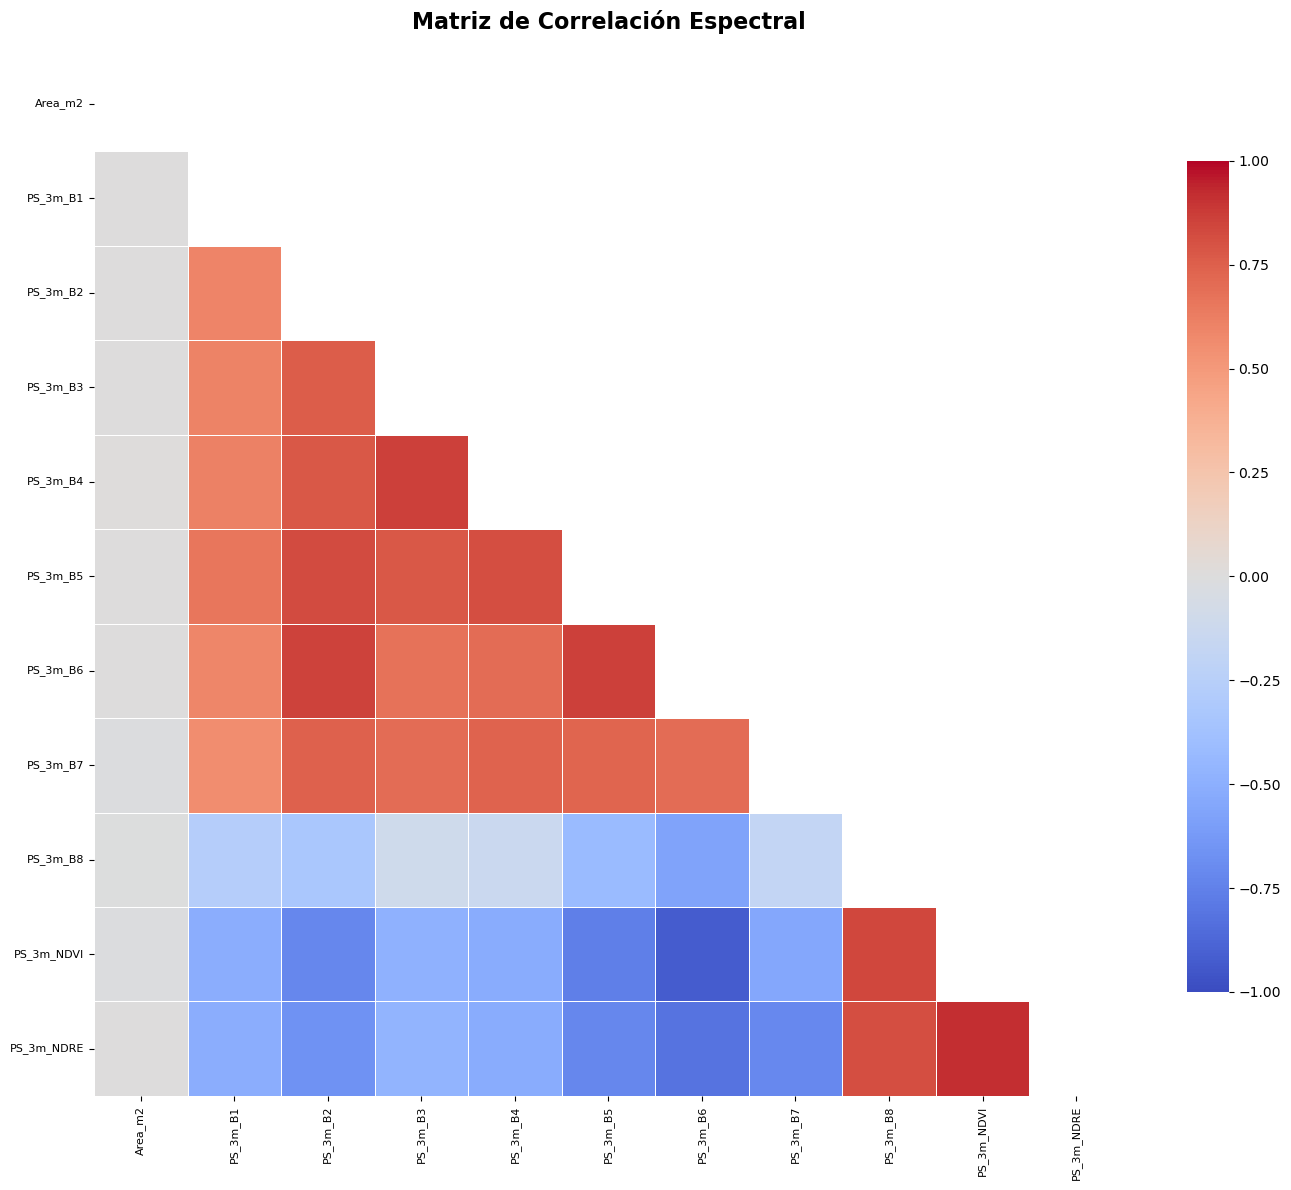


🏆 3. TOP 6 VARIABLES MÁS IMPORTANTES (Random Forest):
Area_m2       0.8170
PS_3m_B7      0.0247
PS_3m_B8      0.0220
PS_3m_NDVI    0.0202
PS_3m_NDRE    0.0188
PS_3m_B6      0.0178
PS_3m_B5      0.0176
PS_3m_B3      0.0176
PS_3m_B4      0.0154
PS_3m_B2      0.0147
dtype: float64

🎨 4. GENERANDO GRÁFICOS DE SEPARABILIDAD (Solo el Top 6)...


C:\Users\48755625H\AppData\Local\Temp\ipykernel_27244\2098008822.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_target, y=var, ax=axes[fila, col], palette='Set2')
C:\Users\48755625H\AppData\Local\Temp\ipykernel_27244\2098008822.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_target, y=var, ax=axes[fila, col], palette='Set2')
C:\Users\48755625H\AppData\Local\Temp\ipykernel_27244\2098008822.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x=col_target, y=var, ax=axes[fila, col], palette='Se

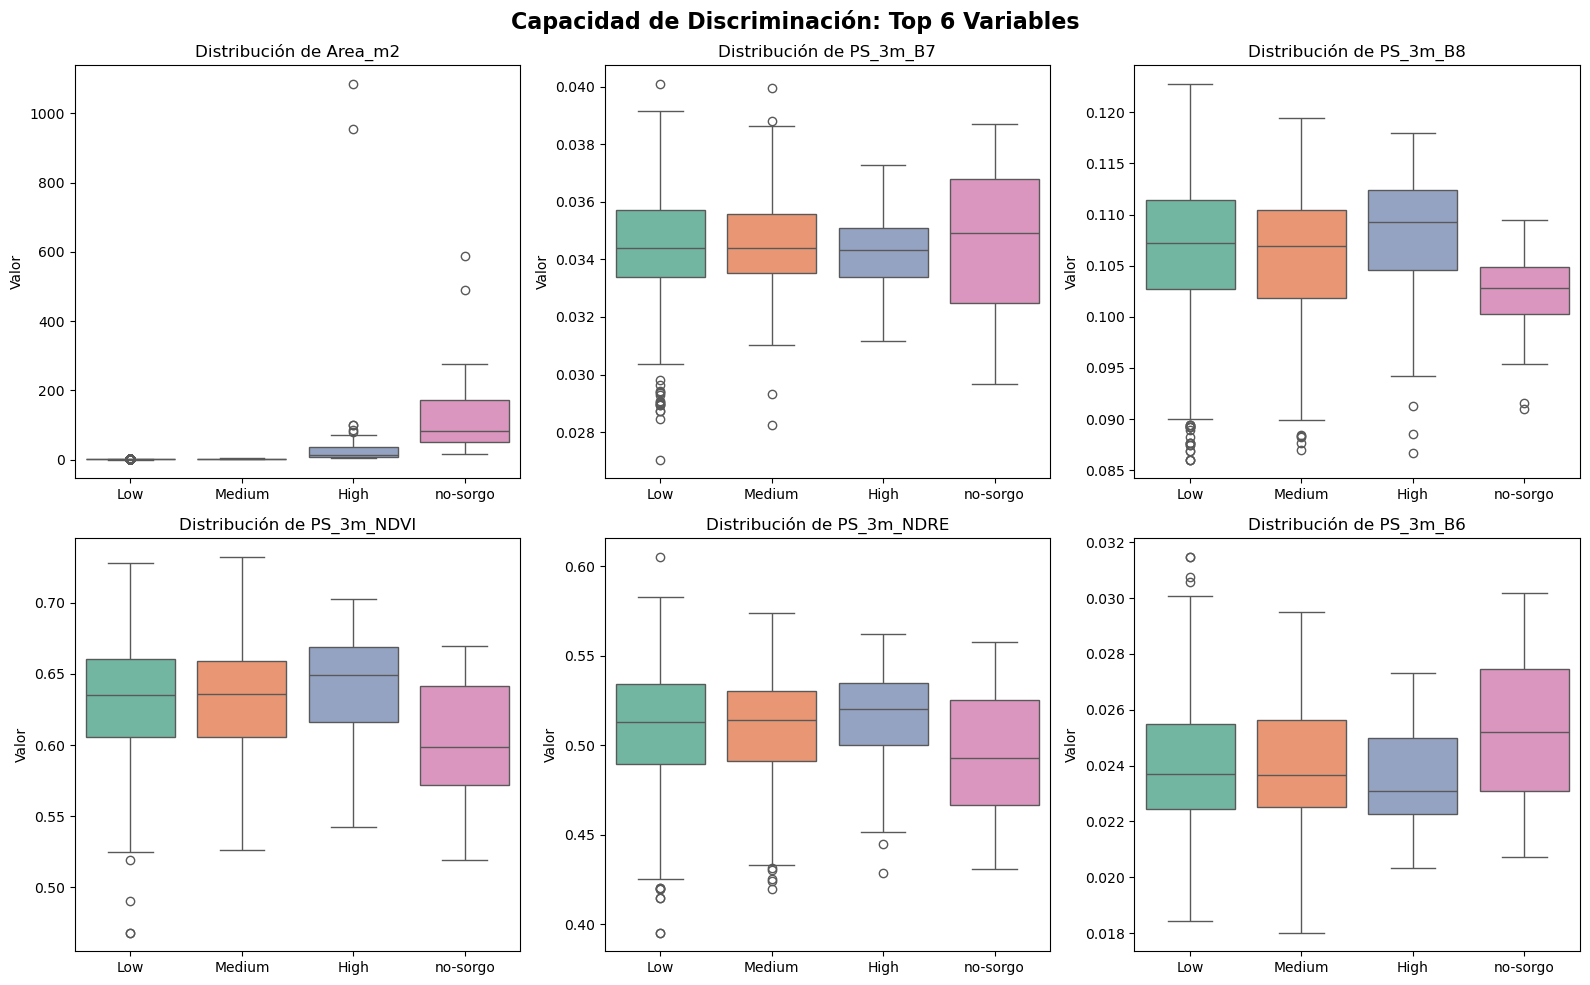

In [8]:
def eda_clasificacion_rapido(df, col_target='Patch_size'):
    print("🚀 INICIANDO EDA DE ALTO IMPACTO...\n")
    
    # Separar variables numéricas (tus bandas e índices)
    X = df.select_dtypes(include=[np.number]).dropna(axis=1, how='all')
    y = df[col_target]
    
    # ---------------------------------------------------------
    # 1. SALUD DE LOS DATOS Y BALANCE DE CLASES
    # ---------------------------------------------------------
    print("📊 1. BALANCE DE CLASES (TARGET):")
    print(y.value_counts(normalize=True).round(3) * 100, "%")
    print("-" * 50)
    
    # ---------------------------------------------------------
    # 2. FILTRO DE REDUNDANCIA (ALTA CORRELACIÓN)
    # ---------------------------------------------------------
    print("🔗 2. ALERTA DE MULTICOLINEALIDAD (> 0.90 Pearson):")
    matriz_corr = X.corr()
    matriz_corr_abs = matriz_corr.abs()
    
    upper = matriz_corr_abs.where(np.triu(np.ones(matriz_corr_abs.shape), k=1).astype(bool))
    vars_a_eliminar = [col for col in upper.columns if any(upper[col] > 0.90)]
    
    if vars_a_eliminar:
        print(f"⚠️ Hay {len(vars_a_eliminar)} variables redundantes.")
        print(f"Ejemplos: {vars_a_eliminar[:10]}...") 
    else:
        print("✅ No hay variables altamente correlacionadas.")
    print("-" * 50)
    
    # ---------------------------------------------------------
    # NUEVO: 2.5 GRÁFICA DE LA MATRIZ DE CORRELACIÓN
    # ---------------------------------------------------------
    print("\n🗺️ GENERANDO MAPA DE CALOR DE CORRELACIÓN...")
    plt.figure(figsize=(14, 12))
    
    # Crear una máscara para ocultar el triángulo superior
    mask = np.triu(np.ones_like(matriz_corr, dtype=bool))
    
    # Generar el heatmap con colores frío-calor (azul negativo, rojo positivo)
    sns.heatmap(matriz_corr, mask=mask, cmap='coolwarm', vmin=-1, vmax=1, 
                annot=False, linewidths=0.5, cbar_kws={"shrink": .8})
    
    plt.title('Matriz de Correlación Espectral', fontsize=16, fontweight='bold', pad=20)
    plt.xticks(fontsize=8, rotation=90)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 3. SELECCIÓN POR FUERZA BRUTA (RANDOM FOREST)
    # ---------------------------------------------------------
    print("\n🏆 3. TOP 6 VARIABLES MÁS IMPORTANTES (Random Forest):")
    X_rf = X.fillna(0) 
    
    rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_rf, y)
    
    importancias = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)
    top_6_vars = importancias.head(6).index
    print(importancias.head(10).round(4))
    
    # ---------------------------------------------------------
    # 4. VISUALIZACIÓN DEL TOP 6 (BOXPLOTS)
    # ---------------------------------------------------------
    print("\n🎨 4. GENERANDO GRÁFICOS DE SEPARABILIDAD (Solo el Top 6)...")
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle('Capacidad de Discriminación: Top 6 Variables', fontsize=16, fontweight='bold')
    
    for i, var in enumerate(top_6_vars):
        fila, col = i // 3, i % 3
        sns.boxplot(data=df, x=col_target, y=var, ax=axes[fila, col], palette='Set2')
        axes[fila, col].set_title(f"Distribución de {var}")
        axes[fila, col].set_xlabel("")
        axes[fila, col].set_ylabel("Valor")
    
    plt.tight_layout()
    plt.show()

eda_clasificacion_rapido(dfA, col_target='Patch_size')

In [9]:
import pandas as pd
import numpy as np
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import os
import dataframe_image as dfi

# =====================================================================
# 0. DICCIONARIOS DE METADATOS (Bandas y Traducciones)
# =====================================================================
# Longitudes de onda oficiales (nm) para PlanetScope (SuperDove)
bandas_planet = {
    'B1': 'Coastal Blue\n(431-452 nm)', 'B2': 'Blue\n(465-515 nm)', 
    'B3': 'Green I\n(513-549 nm)', 'B4': 'Green II\n(547-583 nm)', 
    'B5': 'Yellow\n(600-620 nm)', 'B6': 'Red\n(650-680 nm)', 
    'B7': 'Red Edge\n(697-713 nm)', 'B8': 'NIR\n(845-885 nm)', 
    'NDVI': 'NDVI', 'NDRE': 'NDRE'
}

# Longitudes de onda oficiales (nm) para WorldView-2
bandas_wv2 = {
    'B1': 'Coastal Blue\n(400-450 nm)', 'B2': 'Blue\n(450-510 nm)', 
    'B3': 'Green\n(510-580 nm)', 'B4': 'Yellow\n(585-625 nm)', 
    'B5': 'Red\n(630-690 nm)', 'B6': 'Red Edge\n(705-745 nm)', 
    'B7': 'NIR 1\n(770-895 nm)', 'B8': 'NIR 2\n(860-1040 nm)', 
    'NDVI': 'NDVI', 'NDRE': 'NDRE'
}

# Traducción y orden deseado de las clases
mapa_clases = {
    'no-sorgo': 'Nula',
    'Low': 'Baja',
    'Medium': 'Media',
    'High': 'Alta'
}
orden_clases = ['Nula', 'Baja', 'Media', 'Alta']

# =====================================================================
# 1. MOTOR ESTADÍSTICO
# =====================================================================
def asignar_letras_tukey(df, col_valor, col_clase='Patch_size'):
    """Ejecuta ANOVA y Tukey HSD. Devuelve 'Media (Letra)'."""
    medias = df.groupby(col_clase)[col_valor].mean().sort_values(ascending=False)
    clases_ordenadas = medias.index.tolist()
    
    tukey = pairwise_tukeyhsd(endog=df[col_valor], groups=df[col_clase], alpha=0.001)
    df_tukey = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    
    letras = {clase: '' for clase in clases_ordenadas}
    letra_actual = ord('a')
    grupos_actuales = [[clases_ordenadas[0]]]
    letras[clases_ordenadas[0]] = chr(letra_actual)
    
    for i in range(1, len(clases_ordenadas)):
        clase_eval = clases_ordenadas[i]
        diferente_a_todos = True
        for idx, grupo in enumerate(grupos_actuales):
            c1, c2 = sorted([grupo[0], clase_eval])
            rechazo = df_tukey[(df_tukey['group1'] == c1) & (df_tukey['group2'] == c2)]['reject'].values[0]
            if not rechazo:
                letras[clase_eval] += chr(ord('a') + idx)
                grupo.append(clase_eval)
                diferente_a_todos = False
        if diferente_a_todos:
            letra_actual += 1
            grupos_actuales.append([clase_eval])
            letras[clase_eval] += chr(letra_actual)
            
    resultados_str = {}
    for clase in clases_ordenadas:
        resultados_str[clase] = f"{medias[clase]:.4f} {letras[clase]}"
    return resultados_str

def crear_tabla_transpuesta(df, prefijo, dict_bandas, col_clase='Patch_size'):
    """Construye la tabla transpuesta con traducciones y metadatos."""
    columnas_espectrales = [c for c in df.columns if c.startswith(prefijo) and c not in ['Patch_size', 'ID_patch', 'Area_m2']]
    
    datos_tabla = {}
    for col in columnas_espectrales:
        nombre_banda_crudo = col.replace(f"{prefijo}_", "")
        # Usamos el diccionario para obtener el nombre científico (o dejamos el crudo si no existe)
        nombre_publicacion = dict_bandas.get(nombre_banda_crudo, nombre_banda_crudo)
        datos_tabla[nombre_publicacion] = asignar_letras_tukey(df, col, col_clase)
        
    # Crear el DataFrame (Bandas = Columnas, Clases = Filas)
    df_tabla = pd.DataFrame(datos_tabla)
    
    # Renombrar el índice (Clases) al español usando el diccionario
    df_tabla.rename(index=mapa_clases, inplace=True)
    
    # Forzar el orden específico de las filas
    orden_presente = [c for c in orden_clases if c in df_tabla.index]
    df_tabla = df_tabla.reindex(orden_presente)
    
    # Nombrar el índice para que quede elegante en la imagen
    df_tabla.index.name = "Nivel de Infestación"
    
    return df_tabla

# =====================================================================
# 2. ESTILO Y EXPORTACIÓN
# =====================================================================
def aplicar_estilo_transpuesto(df, titulo_sensor):
    """Estilo optimizado para tablas anchas."""
    df_estilo = df.copy()
    df_estilo.columns = pd.MultiIndex.from_product([[titulo_sensor], df_estilo.columns])
    
    return df_estilo.style\
        .set_properties(**{
            'text-align': 'center', 
            'padding': '8px 10px',
            'white-space': 'pre-wrap' # Permite los saltos de línea (\n) en los nombres de las bandas
        })\
        .set_table_styles([
            # Cabecera principal (Sensor)
            dict(selector='th.col_heading.level0', props=[('background-color', '#1f3a52'), 
                                                          ('color', 'white'), 
                                                          ('font-size', '15px'),
                                                          ('text-align', 'center'),
                                                          ('border', '1px solid white')]),
            # Cabeceras secundarias (Bandas y nm)
            dict(selector='th.col_heading.level1', props=[('background-color', '#34495e'), 
                                                          ('color', 'white'),
                                                          ('font-size', '12px'),
                                                          ('text-align', 'center'),
                                                          ('border', '1px solid white')]),
            # Nombres de las filas (Nivel de infestación)
            dict(selector='th.row_heading', props=[('background-color', '#ecf0f1'),
                                                   ('color', '#2c3e50'),
                                                   ('font-weight', 'bold'),
                                                   ('text-align', 'left'),
                                                   ('border-right', '2px solid #2c3e50')]),
            # Celdas de datos
            dict(selector='td', props=[('border', '1px solid #ddd')])
        ])

# =====================================================================
# 3. EJECUCIÓN DEL SCRIPT
# =====================================================================
print("🧪 Generando tablas transpuestas (Clases x Bandas)...")
os.makedirs("08_resultados", exist_ok=True)

# --- 1. PLANETSCOPE (3m) ---
tabla_planet = crear_tabla_transpuesta(dfA, "PS_3m", bandas_planet)
estilo_planet = aplicar_estilo_transpuesto(tabla_planet, "PlanetScope MS (3m)")
dfi.export(estilo_planet, "08_resultados/Tabla_ANOVA_Planet_3m_Transpuesta.png", dpi=300, table_conversion="matplotlib")
print("\n--- 1. TABLA PLANETSCOPE (3m) ---")
display(estilo_planet)

# --- 2. WORLDVIEW-2 ORIGINAL (2m) ---
tabla_wv2_2m = crear_tabla_transpuesta(dfB, "WV2_2m", bandas_wv2)
estilo_wv2_2m = aplicar_estilo_transpuesto(tabla_wv2_2m, "WorldView-2 MS (2m)")
dfi.export(estilo_wv2_2m, "08_resultados/Tabla_ANOVA_WV2_2m_Transpuesta.png", dpi=300, table_conversion="matplotlib")
print("\n--- 2. TABLA WORLDVIEW-2 (2m) ---")
display(estilo_wv2_2m)

# --- 3. WORLDVIEW-2 PANSHARPENED (0.5m) ---
tabla_wv2_gs = crear_tabla_transpuesta(dfC, "WV2_05m_GS", bandas_wv2)
estilo_wv2_gs = aplicar_estilo_transpuesto(tabla_wv2_gs, "WorldView-2 Pansharpened GS (0.5m)")
dfi.export(estilo_wv2_gs, "08_resultados/Tabla_ANOVA_WV2_05m_GS_Transpuesta.png", dpi=300, table_conversion="matplotlib")
print("\n--- 3. TABLA WORLDVIEW-2 PANSHARP GS (0.5m) ---")
display(estilo_wv2_gs)

print("\n✅ ¡Éxito! Las 3 tablas transpuestas se han guardado en la carpeta '08_resultados'.")

🧪 Generando tablas transpuestas (Clases x Bandas)...

--- 1. TABLA PLANETSCOPE (3m) ---



--- 2. TABLA WORLDVIEW-2 (2m) ---



--- 3. TABLA WORLDVIEW-2 PANSHARP GS (0.5m) ---



✅ ¡Éxito! Las 3 tablas transpuestas se han guardado en la carpeta '08_resultados'.


In [10]:
import nest_asyncio # <-- La clave para que no falle el motor web en Jupyter
# Activar el parche para permitir la captura web exacta
nest_asyncio.apply()

# =====================================================================
# 0. DICCIONARIOS DE METADATOS (Bandas y Traducciones)
# =====================================================================
bandas_planet = {
    'B1': 'Coastal Blue\n(431-452 nm)', 'B2': 'Blue\n(465-515 nm)', 
    'B3': 'Green I\n(513-549 nm)', 'B4': 'Green II\n(547-583 nm)', 
    'B5': 'Yellow\n(600-620 nm)', 'B6': 'Red\n(650-680 nm)', 
    'B7': 'Red Edge\n(697-713 nm)', 'B8': 'NIR\n(845-885 nm)', 
    'NDVI': 'NDVI', 'NDRE': 'NDRE'
}

bandas_wv2 = {
    'B1': 'Coastal Blue\n(400-450 nm)', 'B2': 'Blue\n(450-510 nm)', 
    'B3': 'Green\n(510-580 nm)', 'B4': 'Yellow\n(585-625 nm)', 
    'B5': 'Red\n(630-690 nm)', 'B6': 'Red Edge\n(705-745 nm)', 
    'B7': 'NIR 1\n(770-895 nm)', 'B8': 'NIR 2\n(860-1040 nm)', 
    'NDVI': 'NDVI', 'NDRE': 'NDRE'
}

mapa_clases = {'no-sorgo': 'Nula', 'Low': 'Baja', 'Medium': 'Media', 'High': 'Alta'}
orden_clases = ['Nula', 'Baja', 'Media', 'Alta']

# =====================================================================
# 1. MOTOR ESTADÍSTICO
# =====================================================================
def asignar_letras_tukey(df, col_valor, col_clase='Patch_size'):
    medias = df.groupby(col_clase)[col_valor].mean().sort_values(ascending=False)
    clases_ordenadas = medias.index.tolist()
    
    tukey = pairwise_tukeyhsd(endog=df[col_valor], groups=df[col_clase], alpha=0.05)
    df_tukey = pd.DataFrame(data=tukey._results_table.data[1:], columns=tukey._results_table.data[0])
    
    letras = {clase: '' for clase in clases_ordenadas}
    letra_actual = ord('a')
    grupos_actuales = [[clases_ordenadas[0]]]
    letras[clases_ordenadas[0]] = chr(letra_actual)
    
    for i in range(1, len(clases_ordenadas)):
        clase_eval = clases_ordenadas[i]
        diferente_a_todos = True
        for idx, grupo in enumerate(grupos_actuales):
            c1, c2 = sorted([grupo[0], clase_eval])
            rechazo = df_tukey[(df_tukey['group1'] == c1) & (df_tukey['group2'] == c2)]['reject'].values[0]
            if not rechazo:
                letras[clase_eval] += chr(ord('a') + idx)
                grupo.append(clase_eval)
                diferente_a_todos = False
        if diferente_a_todos:
            letra_actual += 1
            grupos_actuales.append([clase_eval])
            letras[clase_eval] += chr(letra_actual)
            
    resultados_str = {}
    for clase in clases_ordenadas:
        resultados_str[clase] = f"{medias[clase]:.4f} {letras[clase]}"
    return resultados_str

def crear_tabla_transpuesta(df, prefijo, dict_bandas, col_clase='Patch_size'):
    columnas_espectrales = [c for c in df.columns if c.startswith(prefijo) and c not in ['Patch_size', 'ID_patch', 'Area_m2']]
    
    datos_tabla = {}
    for col in columnas_espectrales:
        nombre_banda_crudo = col.replace(f"{prefijo}_", "")
        nombre_publicacion = dict_bandas.get(nombre_banda_crudo, nombre_banda_crudo)
        datos_tabla[nombre_publicacion] = asignar_letras_tukey(df, col, col_clase)
        
    df_tabla = pd.DataFrame(datos_tabla)
    df_tabla.rename(index=mapa_clases, inplace=True)
    orden_presente = [c for c in orden_clases if c in df_tabla.index]
    df_tabla = df_tabla.reindex(orden_presente)
    df_tabla.index.name = "Nivel de Infestación"
    return df_tabla

# =====================================================================
# 2. ESTILO VISUAL HTML/CSS
# =====================================================================
def aplicar_estilo_transpuesto(df, titulo_sensor):
    df_estilo = df.copy()
    df_estilo.columns = pd.MultiIndex.from_product([[titulo_sensor], df_estilo.columns])
    
    return df_estilo.style\
        .set_properties(**{
            'text-align': 'center', 
            'padding': '12px 15px', # Aumentado el padding para que respire más como en pantalla
            'white-space': 'pre-wrap'
        })\
        .set_table_styles([
            dict(selector='th.col_heading.level0', props=[('background-color', '#1f3a52'), 
                                                          ('color', 'white'), 
                                                          ('font-size', '16px'),
                                                          ('text-align', 'center'),
                                                          ('border', '1px solid white')]),
            dict(selector='th.col_heading.level1', props=[('background-color', '#34495e'), 
                                                          ('color', 'white'),
                                                          ('font-size', '13px'),
                                                          ('text-align', 'center'),
                                                          ('border', '1px solid white')]),
            dict(selector='th.row_heading', props=[('background-color', '#ecf0f1'),
                                                   ('color', '#2c3e50'),
                                                   ('font-weight', 'bold'),
                                                   ('text-align', 'left'),
                                                   ('font-size', '13px'),
                                                   ('border-right', '2px solid #2c3e50')]),
            dict(selector='td', props=[('border', '1px solid #ddd')])
        ])

# =====================================================================
# 3. EXPORTACIÓN EXACTA (Usando el motor web nativo)
# =====================================================================
print("🧪 Generando tablas y exportando imagen fiel a la pantalla...")
os.makedirs("08_resultados", exist_ok=True)

# 1. PlanetScope
dfi.export(estilo_planet, "08_resultados/Tabla_ANOVA_Planet_3m_Transpuesta.png", 
           dpi=300, table_conversion="chrome")
print("\n--- 1. TABLA PLANETSCOPE (3m) ---")
display(estilo_planet)

# 2. WV2 (2m)
dfi.export(estilo_wv2_2m, "08_resultados/Tabla_ANOVA_WV2_2m_Transpuesta.png", 
           dpi=300, table_conversion="chrome")
print("\n--- 2. TABLA WORLDVIEW-2 (2m) ---")
display(estilo_wv2_2m)

# 3. WV2 Pansharp (0.5m)
dfi.export(estilo_wv2_gs, "08_resultados/Tabla_ANOVA_WV2_05m_GS_Transpuesta.png", 
           dpi=300, table_conversion="chrome")
print("\n--- 3. TABLA WORLDVIEW-2 PANSHARP GS (0.5m) ---")
display(estilo_wv2_gs)

print("\n✅ ¡Tablas guardadas con la estética idéntica a la de la pantalla!")

🧪 Generando tablas y exportando imagen fiel a la pantalla...

--- 1. TABLA PLANETSCOPE (3m) ---



--- 2. TABLA WORLDVIEW-2 (2m) ---



--- 3. TABLA WORLDVIEW-2 PANSHARP GS (0.5m) ---



✅ ¡Tablas guardadas con la estética idéntica a la de la pantalla!


In [26]:
# =====================================================================
# 1. PREPARACIÓN DE DATOS (Cargamos ambos shapefiles)
# =====================================================================
print("🧹 Cargando y filtrando los shapefiles...")

# Cargar y limpiar Shapefile de Planet / Dron
gdf_pln = gpd.read_file(shp_pln)
gdf_pln_limpio = gdf_pln[gdf_pln['Patch_size'] != 'no-sorgo'].copy()
gdf_pln_limpio.geometry = gdf_pln_limpio.geometry.make_valid()

# Cargar y limpiar Shapefile de WorldView-2
gdf_wv2 = gpd.read_file(shp_wv2)
gdf_wv2_limpio = gdf_wv2[gdf_wv2['Patch_size'] != 'no-sorgo'].copy()
gdf_wv2_limpio.geometry = gdf_wv2_limpio.geometry.make_valid()

print(f"✅ Planet/Dron -> Retenidos: {len(gdf_pln_limpio)}")
print(f"✅ WorldView-2 -> Retenidos: {len(gdf_wv2_limpio)}")

🧹 Cargando y filtrando los shapefiles...
✅ Planet/Dron -> Retenidos: 1836
✅ WorldView-2 -> Retenidos: 1836


🧹 Cargando y reparando shapefiles...
✅ Todos los Shapefiles (Límites y Rodales) listos.
🎨 Generando cuadrícula enmascarada (Corrigiendo desfase de píxeles)...


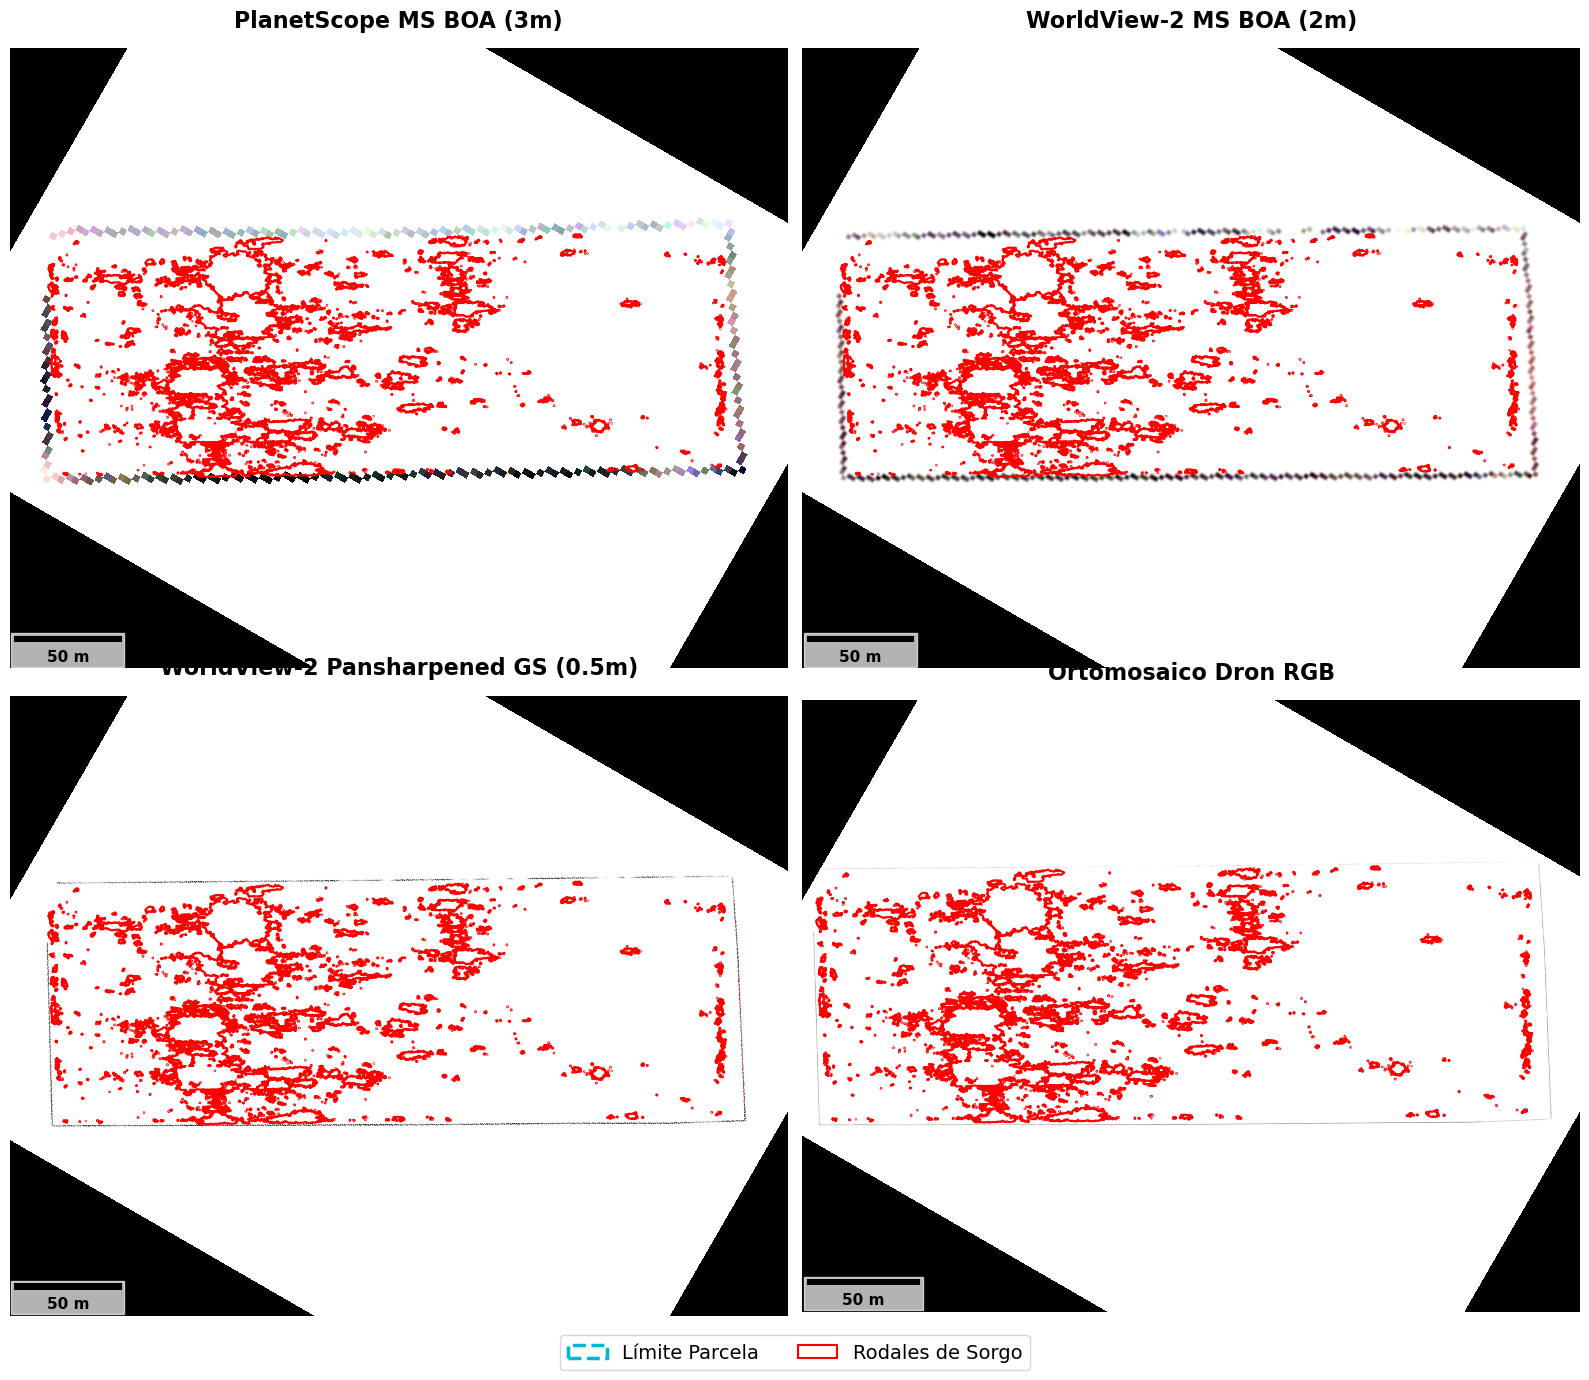

✅ ¡Figura completada y guardada en: 08_resultados/Cuadricula_Parcela_Enmascarada.png!


In [27]:
# =====================================================================
# 1. PREPARACIÓN DE DATOS VECTORIALES (Doble límite)
# =====================================================================
print("🧹 Cargando y reparando shapefiles...")

# --- 1. LÍMITES DE PARCELA ---
# Límite alineado con Planet / Dron
gdf_limite_pln = gpd.read_file(shp_bounds)
gdf_limite_pln.geometry = gdf_limite_pln.geometry.make_valid()

# Límite alineado con WorldView-2
gdf_limite_wv2 = gpd.read_file(shp_bounds_wv2)
gdf_limite_wv2.geometry = gdf_limite_wv2.geometry.make_valid()

print("✅ Todos los Shapefiles (Límites y Rodales) listos.")

# =====================================================================
# 2. MOTOR DE TRATAMIENTO ESPECTRAL
# =====================================================================
def realce_color_boa(arr, pmin=2, pmax=98):
    """Estiramiento de contraste rápido. Ignora los valores 0."""
    arr_nulo = arr == 0
    arr_out = np.zeros_like(arr, dtype=np.float32)
    for i in range(arr.shape[0]):
        banda = arr[i]
        b_valida = banda[banda > 0]
        if len(b_valida) == 0: continue
        vmin, vmax = np.percentile(b_valida, (pmin, pmax))
        if vmax == vmin: vmax += 1e-5
        banda_estirada = np.clip((banda - vmin) / (vmax - vmin), 0, 1)
        arr_out[i] = banda_estirada
    arr_out[arr_nulo] = 0
    return arr_out

# =====================================================================
# 3. MOTOR GRÁFICO (Máscara Blanca + Rotación)
# =====================================================================
def generar_cuadricula_ultra_rapida(dict_imagenes, angulo_rotacion=-30, buffer_visual=15):
    print("🎨 Generando cuadrícula enmascarada (Corrigiendo desfase de píxeles)...")
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 14), facecolor='white')
    axes = axes.flatten()
    
    patch_azul = mpatches.Patch(edgecolor='#00b4d8', facecolor='none', label='Límite Parcela', linewidth=2.5, linestyle='--')
    patch_rojo = mpatches.Patch(edgecolor='red', facecolor='none', label='Rodales de Sorgo', linewidth=1.5)
    
    for idx, (titulo, config) in enumerate(dict_imagenes.items()):
        ax = axes[idx]
        ruta_raster = config['ruta']
        bandas_rgb = config['rgb']
        gdf_rodales = config['gdf_rodales']
        gdf_limite = config['gdf_limite']
        
        # Extensión matemática basada en el shapefile del límite
        minx, miny, maxx, maxy = gdf_limite.total_bounds
        p_xmin, p_ymin = minx - buffer_visual, miny - buffer_visual
        p_xmax, p_ymax = maxx + buffer_visual, maxy + buffer_visual
        
        with rasterio.open(ruta_raster) as src:
            window = from_bounds(p_xmin, p_ymin, p_xmax, p_ymax, src.transform)
            window = window.intersection(rasterio.windows.Window(0, 0, src.width, src.height))
            
            win_xmin, win_ymin, win_xmax, win_ymax = rasterio.windows.bounds(window, src.transform)
            win_w, win_h = int(window.width), int(window.height)
            
            # --- CÁLCULO DE DIMENSIONES DE SALIDA ---
            MAX_DIM = 2000  
            if win_w > MAX_DIM or win_h > MAX_DIM:
                if win_w > win_h:
                    final_w = MAX_DIM
                    final_h = int(win_h * (MAX_DIM / win_w))
                else:
                    final_h = MAX_DIM
                    final_w = int(win_w * (MAX_DIM / win_h))
            else:
                final_h, final_w = win_h, win_w

            # ⚡ SOLUCIÓN AL ERROR DE REDONDEO ⚡
            # 1. Creamos la transformación basada en las coordenadas geográficas de la ventana 
            # y las dimensiones ENTERAS exactas que queremos de salida.
            # (No usamos window_transform * Affine.scale, que es lo que fallaba)
            final_transform = rasterio.transform.from_bounds(win_xmin, win_ymin, win_xmax, win_ymax, final_w, final_h)
            
            # 2. Leemos la imagen (Submuestreando si es el dron)
            if win_w > MAX_DIM or win_h > MAX_DIM:
                out_image = src.read(
                    [int(b) for b in bandas_rgb],
                    window=window,
                    out_shape=(len(bandas_rgb), final_h, final_w), # Usamos las dimensiones calculadas
                    resampling=Resampling.bilinear
                )
            else:
                out_image = src.read([int(b) for b in bandas_rgb], window=window)
            
            # Obtenemos la forma real de la imagen leída (para WV2 puede ser distinta a final_h/final_w)
            # esto asegura compatibilidad total.
            bands, real_h, real_w = out_image.shape

            # 3. Calculamos la máscara asegurando que la forma de salida coincida exactamente
            # con la forma real de la imagen leída.
            mascara_fuera = geometry_mask(gdf_limite.geometry, out_shape=(real_h, real_w), transform=final_transform, invert=False)
            
            # Aplica la máscara blanca
            for i in range(out_image.shape[0]):
                out_image[i][mascara_fuera] = 0
                
            arr_estirado = realce_color_boa(out_image)
            
            for i in range(arr_estirado.shape[0]):
                arr_estirado[i][mascara_fuera] = 1.0
                
            img_plot = reshape_as_image(arr_estirado)
            
            # Dibujo y rotación
            cx = (win_xmin + win_xmax) / 2
            cy = (win_ymin + win_ymax) / 2
            tr_rotacion = Affine2D().rotate_deg_around(cx, cy, angulo_rotacion) + ax.transData
            
            im = ax.imshow(img_plot, extent=[win_xmin, win_xmax, win_ymin, win_ymax], origin='upper')
            im.set_transform(tr_rotacion)
            
            gdf_limite.plot(ax=ax, color='none', edgecolor='#00b4d8', linewidth=2.5, linestyle='--', transform=tr_rotacion)
            gdf_rodales.plot(ax=ax, color='none', edgecolor='red', linewidth=1.5, transform=tr_rotacion)
            
            theta = math.radians(angulo_rotacion)
            dx, dy = -math.sin(theta) * 0.08, math.cos(theta) * 0.08
            ax.annotate('N', xy=(0.90 + dx, 0.90 + dy), xytext=(0.90, 0.90), arrowprops=dict(facecolor='black', width=3, headwidth=10), ha='center', va='center', fontsize=14, fontweight='bold', xycoords='axes fraction')
            
            escala = ScaleBar(1, units="m", location="lower left", box_alpha=0.7, font_properties={'weight':'bold', 'size':11})
            ax.add_artist(escala)
            
            ax.set_title(titulo, fontsize=16, fontweight='bold', pad=15)
            ax.axis('off')
            ax.set_xlim(win_xmin, win_xmax)
            ax.set_ylim(win_ymin, win_ymax)

    fig.legend(handles=[patch_azul, patch_rojo], loc='lower center', ncol=2, fontsize=14, frameon=True, bbox_to_anchor=(0.5, 0.02))
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    
    os.makedirs("08_resultados", exist_ok=True)
    ruta_salida = "08_resultados/Cuadricula_Parcela_Enmascarada.png"
    plt.savefig(ruta_salida, dpi=300, bbox_inches='tight')
    plt.show()
    print(f"✅ ¡Figura completada y guardada en: {ruta_salida}!")
# =====================================================================
# 4. CONFIGURACIÓN Y EJECUCIÓN 
# =====================================================================
imagenes_a_procesar = {
    "PlanetScope MS BOA (3m)": {
        "ruta": out_pln, 
        "rgb": [6, 4, 2], 
        "gdf_rodales": gdf_pln_limpio,
        "gdf_limite": gdf_limite_pln
    },
    "WorldView-2 MS BOA (2m)": {
        "ruta": out_ms_wv2, 
        "rgb": [5, 3, 2], 
        "gdf_rodales": gdf_wv2_limpio,
        "gdf_limite": gdf_limite_wv2
    },
    "WorldView-2 Pansharpened GS (0.5m)": {
        "ruta": pansharp_GS, 
        "rgb": [5, 3, 2], 
        "gdf_rodales": gdf_wv2_limpio,
        "gdf_limite": gdf_limite_wv2
    },
    "Ortomosaico Dron RGB": {
        "ruta": ortho_path, 
        "rgb": [1, 2, 3], 
        "gdf_rodales": gdf_pln_limpio,
        "gdf_limite": gdf_limite_pln
    }
}

generar_cuadricula_ultra_rapida(imagenes_a_procesar, angulo_rotacion=-30, buffer_visual=15)